# 서울시 지하철역 출퇴근 시간대 이용 패턴을 활용한 상권 군집화 분석

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

SEED=42

## 2. 데이터 불러오기

In [2]:
# 데이터 로드 
sub_df = pd.read_csv('./data/seoul_subway_information.csv',
                    encoding='cp949',
                     engine='python',
                    on_bad_lines='skip')
sub_df.head()

,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,23시-24시 하차인원,00시-01시 승차인원,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자
0,202509,1호선,동대문,535,13,12099,1984,9918,7427,17438,...,10017,978,3111,5,349,0,0,0,0,20251003
1,202509,1호선,동묘앞,202,4,2934,890,4096,5669,9623,...,4829,171,2095,0,289,0,0,0,0,20251003
2,202509,1호선,서울역,753,35,11376,10334,32529,62503,105429,...,29456,4658,7703,13,173,0,0,0,0,20251003
3,202509,1호선,시청,78,5,1832,6166,4039,35164,7843,...,3512,651,991,1,29,0,0,0,0,20251003
4,202509,1호선,신설동,454,10,9125,2340,10625,9290,24255,...,9200,478,2787,0,0,0,0,0,0,20251003


In [3]:
print(f"Data 크기 확인 : {sub_df.shape}")

Data 크기 확인 : (2847, 52)


## 3. 탐색적 데이터 분석 (EDA)

데이터의 기본적인 정보를 확인합니다.

In [4]:
sub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2847 entries, 0 to 2846
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   사용월           2847 non-null   int64 
 1   호선명           2847 non-null   object
 2   지하철역          2847 non-null   object
 3   04시-05시 승차인원  2847 non-null   int64 
 4   04시-05시 하차인원  2847 non-null   int64 
 5   05시-06시 승차인원  2847 non-null   int64 
 6   05시-06시 하차인원  2847 non-null   int64 
 7   06시-07시 승차인원  2847 non-null   int64 
 8   06시-07시 하차인원  2847 non-null   int64 
 9   07시-08시 승차인원  2847 non-null   int64 
 10  07시-08시 하차인원  2847 non-null   int64 
 11  08시-09시 승차인원  2847 non-null   int64 
 12  08시-09시 하차인원  2847 non-null   int64 
 13  09시-10시 승차인원  2847 non-null   int64 
 14  09시-10시 하차인원  2847 non-null   int64 
 15  10시-11시 승차인원  2847 non-null   int64 
 16  10시-11시 하차인원  2847 non-null   int64 
 17  11시-12시 승차인원  2847 non-null   int64 
 18  11시-12시 하차인원  2847 non-null   int64 
 19  12시-13

출퇴근 시간대 컬럼만 남기고 그 외 시간대 승/하차인원 컬럼은 제거합니다.

In [5]:
select_col = [
    '사용월',
    '호선명',
    '지하철역',
    '07시-08시 승차인원',
    '07시-08시 하차인원',
    '08시-09시 승차인원',
    '08시-09시 하차인원',
    '09시-10시 승차인원',
    '09시-10시 하차인원',
    '17시-18시 승차인원',
    '17시-18시 하차인원',
    '18시-19시 승차인원',
    '18시-19시 하차인원',
    '19시-20시 승차인원',
    '19시-20시 하차인원'
]

sub_df = sub_df[select_col]

sub_df.head()

,사용월,호선명,지하철역,07시-08시 승차인원,07시-08시 하차인원,08시-09시 승차인원,08시-09시 하차인원,09시-10시 승차인원,09시-10시 하차인원,17시-18시 승차인원,17시-18시 하차인원,18시-19시 승차인원,18시-19시 하차인원,19시-20시 승차인원,19시-20시 하차인원
0,202509,1호선,동대문,17438,12154,24011,20554,22384,22572,27780,23950,25027,24785,19397,23660
1,202509,1호선,동묘앞,9623,11460,15217,24533,12422,17090,31318,15389,21737,13692,11011,9773
2,202509,1호선,서울역,105429,134137,169793,262118,120800,179302,236554,154646,261505,183403,142252,122023
3,202509,1호선,시청,7843,91024,11334,224375,15339,99634,108827,30678,175786,26837,68116,13900
4,202509,1호선,신설동,24255,27377,35323,58887,23836,34383,44246,27384,53907,33389,21114,23993


In [6]:
sub_df['호선명'].unique()

array(['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선', '9호선',
       '9호선2~3단계', '경강선', '경부선', '경원선', '경의선', '경인선', '경춘선', '공항철도 1호선',
       '과천선', '분당선', '서해선', '수인선', '신림선', '안산선', '우이신설선', '일산선', '장항선',
       '중앙선'], dtype=object)

In [7]:
sub_df[sub_df['호선명']=='9호선2~3단계']

,사용월,호선명,지하철역,07시-08시 승차인원,07시-08시 하차인원,08시-09시 승차인원,08시-09시 하차인원,09시-10시 승차인원,09시-10시 하차인원,17시-18시 승차인원,17시-18시 하차인원,18시-19시 승차인원,18시-19시 하차인원,19시-20시 승차인원,19시-20시 하차인원
301,202509,9호선2~3단계,둔촌오륜,26113,4031,23848,4668,13318,2617,5872,12728,4629,21606,2880,17646
302,202509,9호선2~3단계,봉은사,10430,51620,11490,135704,10550,95886,98335,31299,125406,30220,61863,19066
303,202509,9호선2~3단계,삼성중앙,7049,21602,9227,55190,7481,39601,31801,13358,51539,14479,20894,10022
304,202509,9호선2~3단계,삼전,26334,6823,40571,21120,25699,10314,15075,19157,19727,31907,9373,25269
305,202509,9호선2~3단계,석촌,27897,6355,38477,13911,24894,12725,18516,23483,19651,34746,11991,27776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2797,202505,9호선2~3단계,언주,7342,24135,10628,67031,10059,51182,42771,14136,57286,15411,28195,10475
2798,202505,9호선2~3단계,올림픽공원(한국체대),17306,6856,20244,19116,13969,15256,19311,33502,19465,30990,18865,20172
2799,202505,9호선2~3단계,종합운동장,10064,6347,13344,11697,9134,9909,13221,15046,13241,18519,9105,12033
2800,202505,9호선2~3단계,중앙보훈병원,49486,13052,52045,22773,32701,14811,21870,25033,16477,40232,7949,30696


가독성을 높이기 위해 '9호선 2~3단계' 컬럼의 이름을 '9호선'으로 통일합니다.

In [8]:
sub_df['호선명'] = sub_df['호선명'].replace('9호선2~3단계', '9호선')
sub_df['호선명'].unique()

array(['1호선', '2호선', '3호선', '4호선', '5호선', '6호선', '7호선', '8호선', '9호선',
       '경강선', '경부선', '경원선', '경의선', '경인선', '경춘선', '공항철도 1호선', '과천선', '분당선',
       '서해선', '수인선', '신림선', '안산선', '우이신설선', '일산선', '장항선', '중앙선'],
      dtype=object)

## 4. 피처 엔지니어링

시간대별 승/하차인원을 합산하여 새로운 컬럼을 생성합니다.

In [9]:
# 출근 승/하차인원 합산
sub_df['출근_승차인원'] = sub_df['07시-08시 승차인원'] + sub_df['08시-09시 승차인원'] + sub_df['09시-10시 승차인원']
sub_df['출근_하차인원'] = sub_df['07시-08시 하차인원'] + sub_df['08시-09시 하차인원'] + sub_df['09시-10시 하차인원']

# 퇴근 승/하차인원 합산
sub_df['퇴근_승차인원'] = sub_df['17시-18시 승차인원'] + sub_df['18시-19시 승차인원'] + sub_df['19시-20시 승차인원']
sub_df['퇴근_하차인원'] = sub_df['17시-18시 하차인원'] + sub_df['18시-19시 하차인원'] + sub_df['19시-20시 하차인원']

In [10]:
# 추가된 컬럼 확인
sub_df.head()

,사용월,호선명,지하철역,07시-08시 승차인원,07시-08시 하차인원,08시-09시 승차인원,08시-09시 하차인원,09시-10시 승차인원,09시-10시 하차인원,17시-18시 승차인원,17시-18시 하차인원,18시-19시 승차인원,18시-19시 하차인원,19시-20시 승차인원,19시-20시 하차인원,출근_승차인원,출근_하차인원,퇴근_승차인원,퇴근_하차인원
0,202509,1호선,동대문,17438,12154,24011,20554,22384,22572,27780,23950,25027,24785,19397,23660,63833,55280,72204,72395
1,202509,1호선,동묘앞,9623,11460,15217,24533,12422,17090,31318,15389,21737,13692,11011,9773,37262,53083,64066,38854
2,202509,1호선,서울역,105429,134137,169793,262118,120800,179302,236554,154646,261505,183403,142252,122023,396022,575557,640311,460072
3,202509,1호선,시청,7843,91024,11334,224375,15339,99634,108827,30678,175786,26837,68116,13900,34516,415033,352729,71415
4,202509,1호선,신설동,24255,27377,35323,58887,23836,34383,44246,27384,53907,33389,21114,23993,83414,120647,119267,84766


In [11]:
sub_df['지하철역'].unique()

array(['동대문', '동묘앞', '서울역', '시청', '신설동', '제기동', '종각', '종로3가', '종로5가',
       '청량리(서울시립대입구)', '강남', '강변(동서울터미널)', '건대입구', '교대(법원.검찰청)',
       '구로디지털단지', '구의(광진구청)', '낙성대(강감찬)', '당산', '대림(구로구청)', '도림천',
       '동대문역사문화공원(DDP)', '뚝섬', '문래', '방배', '봉천', '사당', '삼성(무역센터)', '상왕십리',
       '서울대입구(관악구청)', '서초', '선릉', '성수', '신답', '신당', '신대방', '신도림', '신림',
       '신정네거리', '신촌', '아현', '양천구청', '역삼', '영등포구청', '왕십리(성동구청)', '용답',
       '용두(동대문구청)', '을지로3가', '을지로4가', '을지로입구', '이대', '잠실(송파구청)', '잠실나루',
       '잠실새내', '종합운동장', '충정로(경기대입구)', '한양대', '합정', '홍대입구', '가락시장',
       '경복궁(정부서울청사)', '경찰병원', '고속터미널', '구파발', '금호', '남부터미널(예술의전당)', '녹번',
       '대청', '대치', '도곡', '독립문', '동대입구', '매봉', '무악재', '불광', '수서', '신사',
       '안국', '압구정', '약수', '양재(서초구청)', '연신내', '오금', '옥수', '일원', '잠원', '지축',
       '충무로', '학여울', '홍제', '길음', '남태령', '노원', '동작(현충원)', '명동',
       '미아(서울사이버대학)', '미아사거리', '불암산', '삼각지(전쟁기념관)', '상계', '성신여대입구(돈암)',
       '수유(강북구청)', '숙대입구(갈월)', '신용산', '쌍문', '이촌(국립중앙박물관)', '창동',
       '총신대입구(이수)', '

역 이름을 보기 쉽게 만들기 위해 괄호가 있는 역은 괄호와 그 속의 내용을 제거합니다.

In [12]:
def cleaned_station_name(text):
    pattern = r'\([^)]*\)'
    text = re.sub(pattern, repl='', string=text)
    return text

sub_df['지하철역'] = sub_df['지하철역'].map(cleaned_station_name)

In [13]:
# 변경된 역이름 확인
sub_df['지하철역'].unique()

array(['동대문', '동묘앞', '서울역', '시청', '신설동', '제기동', '종각', '종로3가', '종로5가',
       '청량리', '강남', '강변', '건대입구', '교대', '구로디지털단지', '구의', '낙성대', '당산',
       '대림', '도림천', '동대문역사문화공원', '뚝섬', '문래', '방배', '봉천', '사당', '삼성',
       '상왕십리', '서울대입구', '서초', '선릉', '성수', '신답', '신당', '신대방', '신도림', '신림',
       '신정네거리', '신촌', '아현', '양천구청', '역삼', '영등포구청', '왕십리', '용답', '용두',
       '을지로3가', '을지로4가', '을지로입구', '이대', '잠실', '잠실나루', '잠실새내', '종합운동장',
       '충정로', '한양대', '합정', '홍대입구', '가락시장', '경복궁', '경찰병원', '고속터미널', '구파발',
       '금호', '남부터미널', '녹번', '대청', '대치', '도곡', '독립문', '동대입구', '매봉', '무악재',
       '불광', '수서', '신사', '안국', '압구정', '약수', '양재', '연신내', '오금', '옥수', '일원',
       '잠원', '지축', '충무로', '학여울', '홍제', '길음', '남태령', '노원', '동작', '명동',
       '미아', '미아사거리', '불암산', '삼각지', '상계', '성신여대입구', '수유', '숙대입구', '신용산',
       '쌍문', '이촌', '창동', '총신대입구', '한성대입구', '혜화', '회현', '강동', '강일', '개롱',
       '개화산', '거여', '고덕', '공덕', '광나루', '광화문', '군자', '굽은다리', '길동', '김포공항',
       '까치산', '답십리', '둔촌동', '마곡', '마장', '마천', '마포', '명일', '목동',

In [14]:
# 출/퇴근하는 총인원에 비해 승차, 하차하는 인원의 비율을 확인해 집중도를 파악합니다.
sub_df["출근_총인원"] = sub_df["출근_승차인원"] + sub_df["출근_하차인원"]
sub_df["퇴근_총인원"] = sub_df["퇴근_승차인원"] + sub_df["퇴근_하차인원"]

# 출근시간 승/하차 집중도 파악
sub_df["출근_승차_집중도"] = sub_df["출근_승차인원"] / sub_df["출근_총인원"]
sub_df["출근_하차_집중도"] = sub_df["출근_하차인원"] / sub_df["출근_총인원"]

# 퇴근시간 승/하차 집중도 파악
sub_df["퇴근_승차_집중도"] = sub_df["퇴근_승차인원"] / sub_df["퇴근_총인원"]
sub_df["퇴근_하차_집중도"] = sub_df["퇴근_하차인원"] / sub_df["퇴근_총인원"]

In [15]:
# 지하철역을 기준으로 그룹화해, 호선명이 2개 이상인 역은 환승역으로 취급함.
transfer_st = sub_df.groupby("지하철역")["호선명"].nunique()
transfer_st = transfer_st.reset_index()
transfer_st = transfer_st[transfer_st["호선명"] > 1]
transfer_st = transfer_st["지하철역"].tolist()

sub_df["환승역_여부"] = sub_df["지하철역"].isin(transfer_st)
sub_df[sub_df["환승역_여부"] == True].head()

,사용월,호선명,지하철역,07시-08시 승차인원,07시-08시 하차인원,08시-09시 승차인원,08시-09시 하차인원,09시-10시 승차인원,09시-10시 하차인원,17시-18시 승차인원,...,출근_하차인원,퇴근_승차인원,퇴근_하차인원,출근_총인원,퇴근_총인원,출근_승차_집중도,출근_하차_집중도,퇴근_승차_집중도,퇴근_하차_집중도,환승역_여부
0,202509,1호선,동대문,17438,12154,24011,20554,22384,22572,27780,...,55280,72204,72395,119113,144599,0.535903,0.464097,0.499340,0.500660,True
1,202509,1호선,동묘앞,9623,11460,15217,24533,12422,17090,31318,...,53083,64066,38854,90345,102920,0.412441,0.587559,0.622483,0.377517,True
2,202509,1호선,서울역,105429,134137,169793,262118,120800,179302,236554,...,575557,640311,460072,971579,1100383,0.407607,0.592393,0.581898,0.418102,True
3,202509,1호선,시청,7843,91024,11334,224375,15339,99634,108827,...,415033,352729,71415,449549,424144,0.076779,0.923221,0.831626,0.168374,True
4,202509,1호선,신설동,24255,27377,35323,58887,23836,34383,44246,...,120647,119267,84766,204061,204033,0.408770,0.591230,0.584548,0.415452,True


정확한 군집화를 위해 이용객이 너무 적은 역은 제거하고, 상위 70% 이상의 이용인원이 있는 역을 대상으로 분석을 진행합니다.

In [16]:
go_ride_threshold = sub_df['출근_승차인원'].quantile(0.3)
go_alight_threshold = sub_df['출근_하차인원'].quantile(0.3)
leave_ride_threshold = sub_df['퇴근_승차인원'].quantile(0.3)
leave_alight_threshold = sub_df['퇴근_하차인원'].quantile(0.3)

sub_df_filtered = sub_df[
    (sub_df['출근_승차인원'] >= go_ride_threshold) |
    (sub_df['출근_하차인원'] >= go_alight_threshold) |
    (sub_df['퇴근_승차인원'] >= leave_ride_threshold) |
    (sub_df['퇴근_하차인원'] >= leave_alight_threshold) 
]

print(f"필터링 전: {sub_df.shape} -> 필터링 후: {sub_df_filtered.shape}")

필터링 전: (2847, 26) -> 필터링 후: (2342, 26)


결측치가 있는지 확인합니다.

In [17]:
sub_df_filtered.isnull().sum()

사용월             0
호선명             0
지하철역            0
07시-08시 승차인원    0
07시-08시 하차인원    0
08시-09시 승차인원    0
08시-09시 하차인원    0
09시-10시 승차인원    0
09시-10시 하차인원    0
17시-18시 승차인원    0
17시-18시 하차인원    0
18시-19시 승차인원    0
18시-19시 하차인원    0
19시-20시 승차인원    0
19시-20시 하차인원    0
출근_승차인원         0
출근_하차인원         0
퇴근_승차인원         0
퇴근_하차인원         0
출근_총인원          0
퇴근_총인원          0
출근_승차_집중도       0
출근_하차_집중도       0
퇴근_승차_집중도       0
퇴근_하차_집중도       0
환승역_여부          0
dtype: int64

## 5. 정규화 및 모델 생성

In [18]:
# 정규화 진행을 위해 숫자형 컬럼만 선택합니다.
select_cols = ["출근_승차인원", "출근_하차인원", "퇴근_승차인원", "퇴근_하차인원", "출근_승차_집중도", "출근_하차_집중도", "퇴근_승차_집중도", "퇴근_하차_집중도"]

X = sub_df_filtered[select_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=SEED)
y_pred = kmeans.fit_predict(X_scaled)

print(f"생성된 라벨 확인: {y_pred[:10]}")

생성된 라벨 확인: [0 0 2 2 0 0 2 0 0 1]


### 5-1. 클러스터별 '출근 승차 집중도' 분포

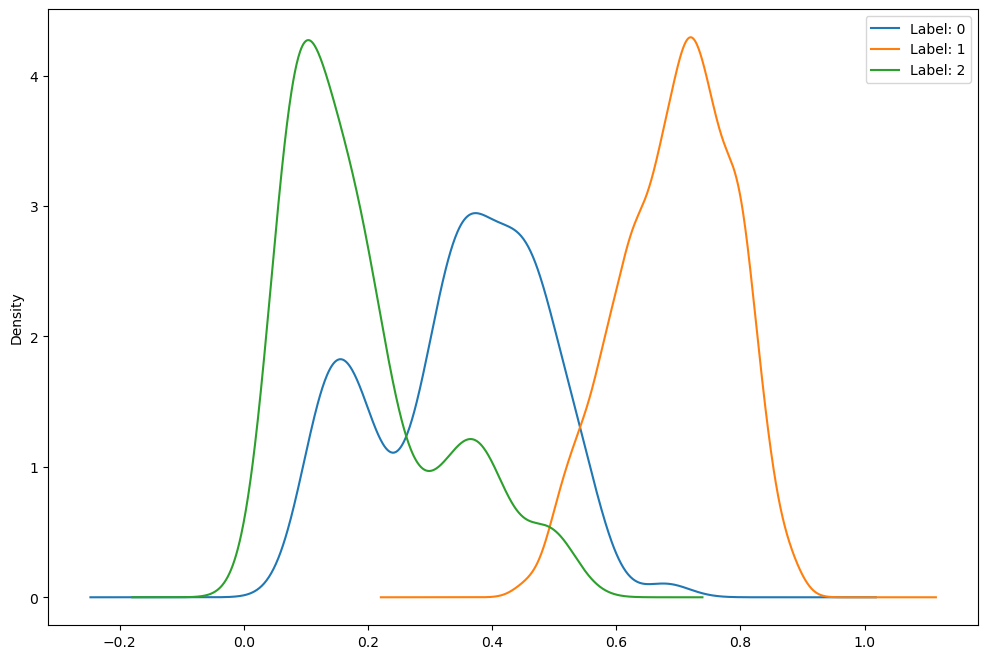

In [19]:
# 클러스터별 집중도 분포 확인
fig = plt.figure(figsize=(12, 8))
ax = plt.gca()

for i in set(y_pred):
    sub_df_filtered[y_pred == i]["출근_승차_집중도"].plot(kind="kde", ax=ax, label=f"Label: {i}")

plt.legend()
plt.show()

Label 0은 높은 쪽의 분포를 가지고 있는 것으로 보아 출근 시간대 승차 인원의 비율이 높은 편이라는 것을 확인할 수 있습니다.
Label 2의 경우에는 보통 수준의 분포를, Label 1의 경우에는 낮은 쪽의 분포를 보입니다.

이 분포 형태로 보자면 Label 0은 출근 시간에 승차하는 인원들로 붐비는 주거지역,
이와 반대의 양상을 보이는 Label 1은 주로 도착지인 직장이 모여있는 상업지역,
그 중간인 Label 2는 복합지역인 것으로 추정됩니다.

### 5-2. 클러스터별 '출근 하차 집중도' 분포

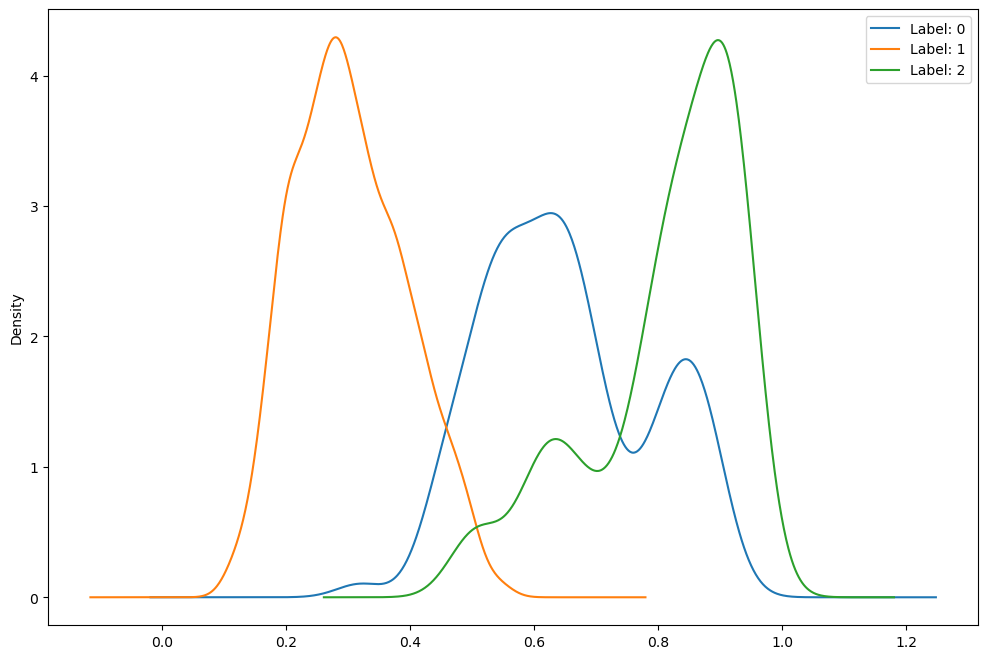

In [20]:
fig = plt.figure(figsize=(12, 8))
ax = plt.gca()

for i in set(y_pred):
    sub_df_filtered[y_pred == i]["출근_하차_집중도"].plot(kind="kde", ax=ax, label=f"Label: {i}")

plt.legend()
plt.show()

다음으로 출근 시간대 하차 집중도의 분포를 살펴보겠습니다.

Label 0은 낮은 쪽의 분포, Label 2는 중간 분포, Label 1은 높은 쪽의 분포를 보이고 있습니다.

출근 시간대 하차 인원의 비율이 높은 Label 1이 상업지역,
그 반대의 분포인 Label 0은 주거지역,
Label 2는 복합지역으로 유추해볼 수 있습니다.

앞선 출근 시간대 승차 인원의 분석 결과와 동일한 군집화 양상을 보이고 있습니다.

### 5-3. 클러스터별 '퇴근 승차 집중도' 분포

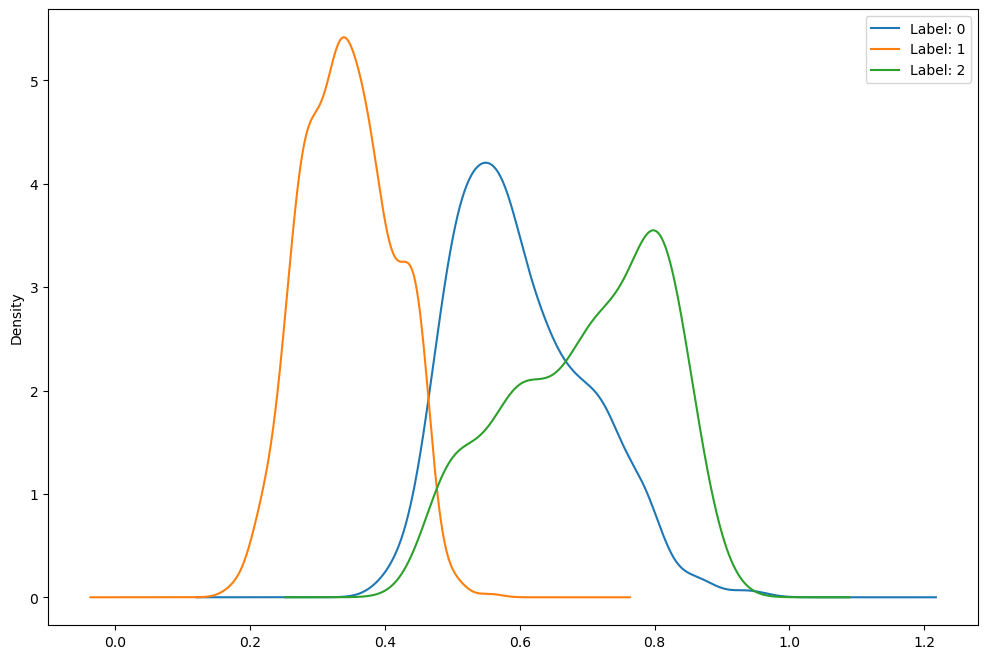

In [21]:
fig = plt.figure(figsize=(12, 8))
ax = plt.gca()

for i in set(y_pred):
    sub_df_filtered[y_pred == i]["퇴근_승차_집중도"].plot(kind="kde", ax=ax, label=f"Label: {i}")

plt.legend()
plt.show()

이번엔 퇴근 시간대의 분포를 살펴보겠습니다.

먼저 승차 인원의 집중도 분포로 볼 때, 
낮은 쪽의 분포를 보이는 Label 0은 퇴근 시간대 승차인원이 적은 주거지역,
중간 분포인 Label 2는 복합지역,
높은 쪽의 분포를 보이는 Label 1은 퇴근 시간대 승차인원이 많은 상업지역으로 파악됩니다.

### 5-4. 클러스터별 '퇴근 하차 집중도' 분포

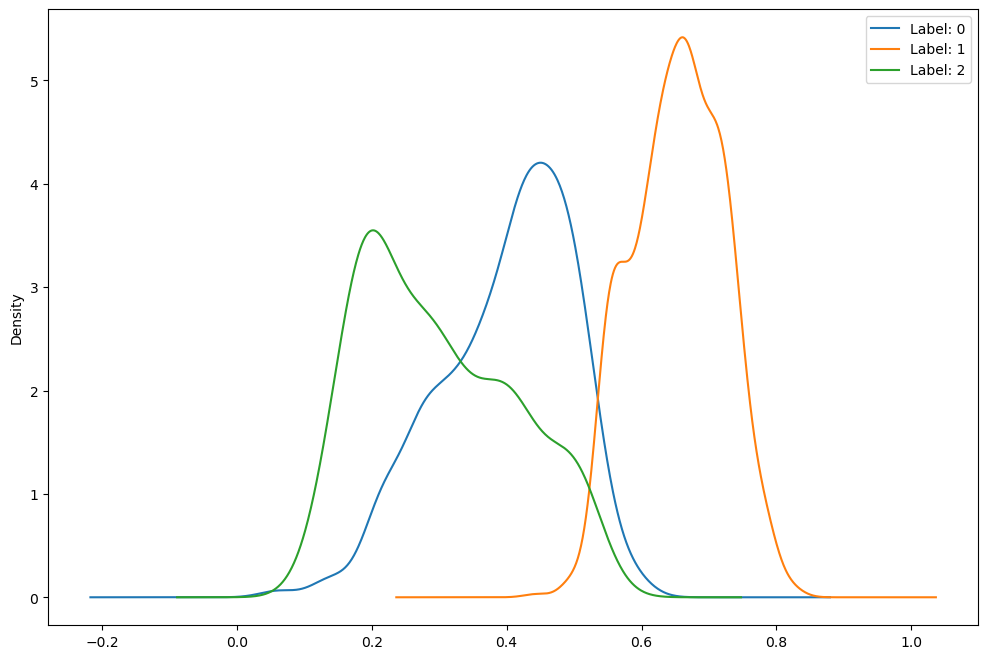

In [22]:
fig = plt.figure(figsize=(12, 8))
ax = plt.gca()

for i in set(y_pred):
    sub_df_filtered[y_pred == i]["퇴근_하차_집중도"].plot(kind="kde", ax=ax, label=f"Label: {i}")

plt.legend()
plt.show()

퇴근 시간대 하차 집중도도 동일한 양상을 보입니다.

퇴근 시간대 하차하는 인원이 비교적 적은 Label 1은 상업지역,
중간 분포인 Label 2는 복합지역,
퇴근 시간대 하차하는 인원이 많은 Label 0이 주거지역으로 보입니다.

4가지 분포 모두 비슷한 결과를 나타내고 있는 것으로 보아, 군집화가 잘 이루어졌다고 판단할 수 있습니다.

### 5-5. 클러스터별 역 이름 확인

실제 군집화된 지하철역 명을 확인해보겠습니다.

In [23]:
for i in set(y_pred):
    print("*" * 25, f"Label: {i}", "*" * 25)
    print(sub_df_filtered[y_pred == i]["지하철역"].sample(n=5))
    print()

************************* Label: 0 *************************
2559     독립문
7       종로3가
2020      양평
2199      남영
1454      합정
Name: 지하철역, dtype: object

************************* Label: 1 *************************
1310     녹번
1599     오산
1899     신당
559     상록수
655     신대방
Name: 지하철역, dtype: object

************************* Label: 2 *************************
2517     선릉
1264     문래
2539     잠실
2606     회현
2635    서대문
Name: 지하철역, dtype: object



## 6. PCA 진행

시각화를 위해 차원축소를 진행합니다.

In [24]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

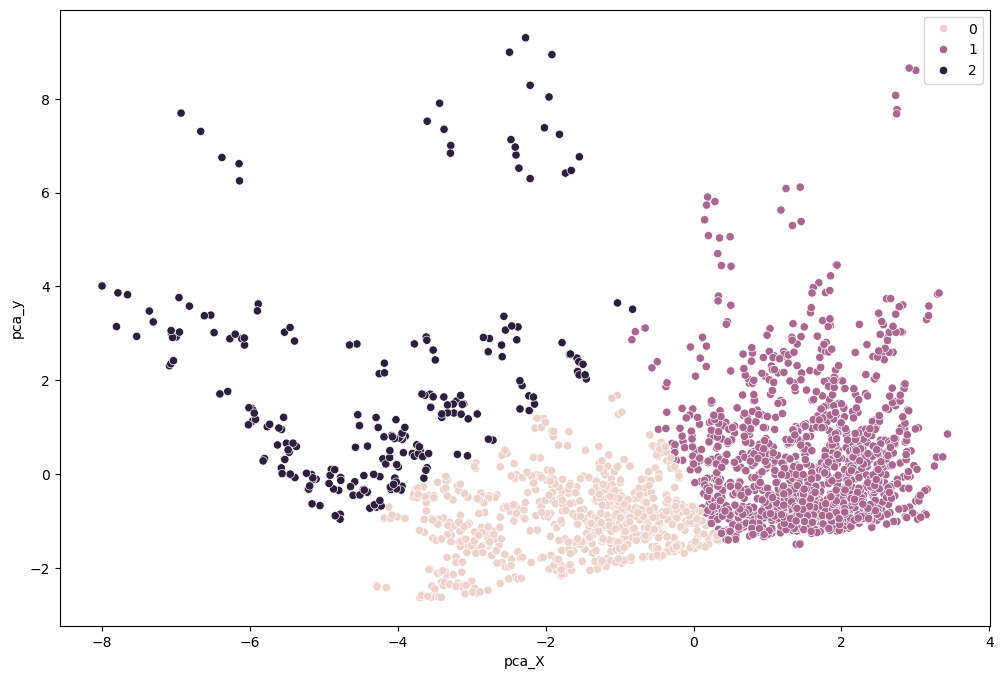

In [25]:
pca_df = pd.DataFrame(
    np.concatenate([X_pca, y_pred[:, np.newaxis]], axis=1),
    columns=["pca_X", "pca_y", "Label"]
)
pca_df["Label"] = pca_df["Label"].astype(int)

fig = plt.figure(figsize=(12,8))
ax = plt.gca()
sns.scatterplot(data=pca_df, x="pca_X", y="pca_y", hue="Label", ax=ax)
plt.legend()
plt.show()

정확한 분석을 위해 각 컬럼의 가중치값을 확인합니다.

In [26]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print(loadings)

                PC1       PC2
출근_승차인원    0.150883  0.553660
출근_하차인원   -0.344600  0.338532
퇴근_승차인원   -0.321830  0.408269
퇴근_하차인원    0.000347  0.613092
출근_승차_집중도  0.436959  0.083639
출근_하차_집중도 -0.436959 -0.083639
퇴근_승차_집중도 -0.431882 -0.105593
퇴근_하차_집중도  0.431882  0.105593


가중치를 바탕으로 산점도를 분석해보면, 
PC1에서 '출근 승차 집중도'와 '퇴근 하차 집중도'가 높은 가중치를 보이고 있습니다.
따라서 PC1 값이 높은 Label 0이 주거지역,

반대로 PC1에서 마이너스 가중치를 보이는 '출근 하차 집중도'와 '퇴근 승차 집중도' 컬럼에 따라, 음수값을 보이는 Label 1이 상업지역,

그 중간의 값인 Label 2가 복합지역이라고 볼 수 있습니다.

이 역시 앞서 확인한 KMeans의 결과와 동일하므로 패턴 분석이 잘 이루어졌다고 판단됩니다.

## 7. 성능 확인

In [27]:
# 실루엣 지표를 활용해 성능을 확인합니다.
score = silhouette_score(X_scaled, y_pred)

print(f"실루엣 스코어: {score:.5f}")

실루엣 스코어: 0.42233


### 7-1. 새로운 변수 추가

위에서 생성해두었던 bool 형식의 '환승역_여부' 컬럼을 정수형으로 변환하여 성능에 변화가 있는지 확인합니다.

In [28]:
# 정수형 변환
sub_df_filtered['환승역_여부'] = sub_df_filtered['환승역_여부'] * 1
sub_df_filtered.head()

/var/folders/xl/hqfx0jqd111gpm_w0lswvptw0000gn/T/ipykernel_43195/4270828976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_filtered['환승역_여부'] = sub_df_filtered['환승역_여부'] * 1


,사용월,호선명,지하철역,07시-08시 승차인원,07시-08시 하차인원,08시-09시 승차인원,08시-09시 하차인원,09시-10시 승차인원,09시-10시 하차인원,17시-18시 승차인원,...,출근_하차인원,퇴근_승차인원,퇴근_하차인원,출근_총인원,퇴근_총인원,출근_승차_집중도,출근_하차_집중도,퇴근_승차_집중도,퇴근_하차_집중도,환승역_여부
0,202509,1호선,동대문,17438,12154,24011,20554,22384,22572,27780,...,55280,72204,72395,119113,144599,0.535903,0.464097,0.499340,0.500660,1
1,202509,1호선,동묘앞,9623,11460,15217,24533,12422,17090,31318,...,53083,64066,38854,90345,102920,0.412441,0.587559,0.622483,0.377517,1
2,202509,1호선,서울역,105429,134137,169793,262118,120800,179302,236554,...,575557,640311,460072,971579,1100383,0.407607,0.592393,0.581898,0.418102,1
3,202509,1호선,시청,7843,91024,11334,224375,15339,99634,108827,...,415033,352729,71415,449549,424144,0.076779,0.923221,0.831626,0.168374,1
4,202509,1호선,신설동,24255,27377,35323,58887,23836,34383,44246,...,120647,119267,84766,204061,204033,0.408770,0.591230,0.584548,0.415452,1


In [29]:
update_cols = ["출근_승차인원", "출근_하차인원", "퇴근_승차인원", "퇴근_하차인원", "출근_승차_집중도", "출근_하차_집중도", "퇴근_승차_집중도", "퇴근_하차_집중도", "환승역_여부"]
X_update = sub_df_filtered[update_cols]
X_scaled_upd = scaler.fit_transform(X_update)

y_pred_upd = kmeans.fit_predict(X_scaled_upd)

score_upd = silhouette_score(X_scaled_upd, y_pred_upd)

print(f"업데이트된 실루엣 스코어: {score_upd:.5f}")

업데이트된 실루엣 스코어: 0.37230


새로운 변수를 추가하여 추가적으로 실루엣 스코어를 예측해본 결과,
오히려 점수가 저하한 것을 볼 수 있습니다. 

이는 환승역 여부를 나타내는 컬럼이 군집 간 경계를 불명확하게 하는 정보라는 것을 추정해볼 수 있습니다.